In [7]:
# ==========================================
# ÍNDICE DE CALIDAD VIAL (ICV)
# CASO: San Miguel, Santiago, Chile
# Enfoque: Data Science + Ingeniería Urbana
# ==========================================

# ⚠️ ESTE SCRIPT ES UN EJEMPLO AVANZADO
# Los alumnos deben:
# - Ajustar ponderaciones
# - Incorporar nuevos datos (INE, accidentes, etc.)
# - Validar supuestos
# - Justificar decisiones

# ==========================================
# 1. LIBRERÍAS
# ==========================================
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np

ox.settings.use_cache = True
ox.settings.log_console = True

In [8]:
# ==========================================
# 2. PARÁMETROS
# ==========================================
place_name = "San Miguel, Santiago, Chile"
CRS_PROY = "EPSG:32719"

# Ponderaciones (AJUSTABLES POR ALUMNOS)
W_CONECTIVIDAD = 0.3
W_ACCESIBILIDAD = 0.25
W_JERARQUIA = 0.2
W_PEATONAL = 0.15
W_EQUIPAMIENTO = 0.1

In [9]:
# ==========================================
# 3. RED VIAL
# ==========================================
G = ox.graph_from_place(place_name, network_type="drive")
nodes, edges = ox.graph_to_gdfs(G)

nodes = nodes.to_crs(CRS_PROY)
edges = edges.to_crs(CRS_PROY)

In [10]:
# ==========================================
# 4. CONECTIVIDAD (VERSIÓN ROBUSTA)
# ==========================================

# Grado del nodo (número de conexiones reales)
degree_dict = dict(G.degree())

# Mapear al GeoDataFrame
nodes["conectividad"] = nodes.index.map(degree_dict)

# Rellenar posibles nulos
nodes["conectividad"] = nodes["conectividad"].fillna(0)

# Normalización
nodes["conectividad_norm"] = (
    nodes["conectividad"] - nodes["conectividad"].min()
) / (nodes["conectividad"].max() - nodes["conectividad"].min())

In [11]:
# ==========================================
# 5. JERARQUÍA VIAL
# ==========================================
def clasificar_jerarquia(highway):
    if isinstance(highway, list):
        highway = highway[0]
        
    if highway in ["motorway", "trunk", "primary"]:
        return 1.0
    elif highway in ["secondary"]:
        return 0.7
    elif highway in ["tertiary"]:
        return 0.5
    else:
        return 0.3

edges["jerarquia"] = edges["highway"].apply(clasificar_jerarquia)

# Promediar jerarquía en nodos
jerarquia_nodos = edges.groupby("u")["jerarquia"].mean()
nodes["jerarquia"] = nodes.index.map(jerarquia_nodos)

nodes["jerarquia_norm"] = (
    nodes["jerarquia"] - nodes["jerarquia"].min()
) / (nodes["jerarquia"].max() - nodes["jerarquia"].min())

In [12]:
# ==========================================
# 6. ACCESIBILIDAD A SERVICIOS
# ==========================================

tags_servicios = {"amenity": True}

# Compatibilidad con versiones antiguas de OSMnx
servicios = ox.features_from_place(place_name, tags_servicios)

# Eliminar geometrías nulas
servicios = servicios[servicios.geometry.notnull()]

# Reproyectar
servicios = servicios.to_crs(CRS_PROY)

# Convertir TODO a centroides (homogeneizar)
servicios["geometry"] = servicios.geometry.centroid

# Evitar errores si queda vacío
if len(servicios) == 0:
    print("⚠ No hay servicios disponibles")
    nodes["accesibilidad"] = 0
    nodes["accesibilidad_norm"] = 0
else:
    # Calcular distancia mínima a servicios
    nodes["dist_servicio"] = nodes.geometry.apply(
        lambda x: servicios.distance(x).min()
    )

    # Invertir distancia (más cerca = mejor)
    nodes["accesibilidad"] = 1 / (nodes["dist_servicio"] + 1)

    # Normalizar
    nodes["accesibilidad_norm"] = (
        nodes["accesibilidad"] - nodes["accesibilidad"].min()
    ) / (nodes["accesibilidad"].max() - nodes["accesibilidad"].min())

print("✔ Accesibilidad calculada")

✔ Accesibilidad calculada


In [13]:
# ==========================================
# 7. INFRAESTRUCTURA PEATONAL (ROBUSTO)
# ==========================================

tags_walk = {"highway": ["footway", "pedestrian", "path"]}

# Compatibilidad con versión antigua
walkways = ox.features_from_place(place_name, tags_walk)

# Limpiar geometrías
walkways = walkways[walkways.geometry.notnull()]

# Reproyectar
walkways = walkways.to_crs(CRS_PROY)

# Validar datos
if len(walkways) == 0:
    print("⚠ No hay infraestructura peatonal")
    nodes["peatonal"] = 0
    nodes["peatonal_norm"] = 0
else:
    # Calcular densidad peatonal por nodo
    def densidad_peatonal(punto):
        buffer = punto.buffer(200)
        return walkways.intersects(buffer).sum()

    nodes["peatonal"] = nodes.geometry.apply(densidad_peatonal)

    # Normalización
    nodes["peatonal_norm"] = (
        nodes["peatonal"] - nodes["peatonal"].min()
    ) / (nodes["peatonal"].max() - nodes["peatonal"].min())

print("✔ Infraestructura peatonal calculada")

✔ Infraestructura peatonal calculada


In [14]:
# ==========================================
# 8. DENSIDAD DE EQUIPAMIENTO
# ==========================================
tags_pois = {"amenity": True, "shop": True}
pois = ox.features_from_place(place_name, tags_pois)

pois = pois.to_crs(CRS_PROY)
pois["geometry"] = pois.geometry.centroid

def densidad_pois(punto):
    buffer = punto.buffer(300)
    return pois.intersects(buffer).sum()

nodes["equipamiento"] = nodes.geometry.apply(densidad_pois)

nodes["equipamiento_norm"] = (
    nodes["equipamiento"] - nodes["equipamiento"].min()
) / (nodes["equipamiento"].max() - nodes["equipamiento"].min())

In [15]:
# ==========================================
# 9. ÍNDICE DE CALIDAD VIAL (ICV)
# ==========================================
nodes["ICV"] = (
    W_CONECTIVIDAD * nodes["conectividad_norm"] +
    W_ACCESIBILIDAD * nodes["accesibilidad_norm"] +
    W_JERARQUIA * nodes["jerarquia_norm"] +
    W_PEATONAL * nodes["peatonal_norm"] +
    W_EQUIPAMIENTO * nodes["equipamiento_norm"]
)

In [16]:
# ==========================================
# 10. EXPORTACIÓN
# ==========================================
nodes.to_file("indice_calidad_vial_nodos.shp")

print("✔ Índice de Calidad Vial generado")

✔ Índice de Calidad Vial generado


C:\Users\anton\AppData\Local\Temp\ipykernel_8476\3635553932.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file("indice_calidad_vial_nodos.shp")
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'conectividad' to 'conectivid'
  ogr_write(
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'conectividad_norm' to 'conectiv_1'
  ogr_write(
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'jerarquia_norm' to 'jerarquia_'
  ogr_write(
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\pyogrio\raw.py:7

<Axes: >

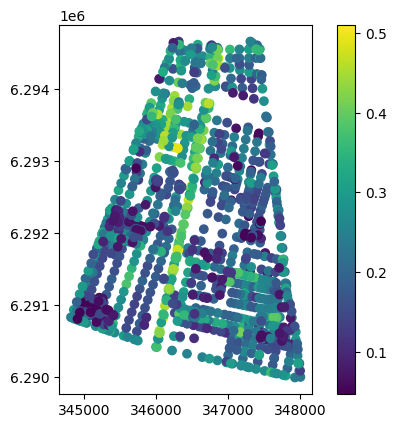

In [17]:
# ==========================================
# 11. VISUALIZACIÓN RÁPIDA
# ==========================================
nodes.plot(column="ICV", cmap="viridis", legend=True)

In [18]:
# ==========================================
# 12. REFLEXIÓN (PARA ALUMNOS)
# ==========================================
print("""
Este índice es un modelo simplificado.

Desafíos para mejorar:
- Incorporar accidentes (CONASET)
- Usar centralidad real (betweenness)
- Incluir tráfico
- Considerar calidad de pavimento
- Incluir datos socioeconómicos
- Validar ponderaciones

El valor está en el modelo, no en el número final.
""")


Este índice es un modelo simplificado.

Desafíos para mejorar:
- Incorporar accidentes (CONASET)
- Usar centralidad real (betweenness)
- Incluir tráfico
- Considerar calidad de pavimento
- Incluir datos socioeconómicos
- Validar ponderaciones

El valor está en el modelo, no en el número final.

